In [2]:
import numpy as np
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import pickle

from spectral.io import envi
from spectral.io.envi import read_envi_header

from scipy.signal import medfilt, savgol_filter
from scipy.interpolate import splrep, splev, interp1d

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.radiative_transfer.radiative_transfer import RadiativeTransfer
from isofit.radiative_transfer import luts
import logging

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

%matplotlib widget

os.chdir('/store/carroll/col/data/')

In [82]:
wl = np.loadtxt('wavelengths_neon.txt')[:,1]*1000
wl_nan = np.loadtxt('wl_nan.txt')

base_dir = '2025/rccs/'

# prepare representative single pxs
fp = '2025/rccs/single_pxs.pkl'
with open(fp, 'rb') as f:
    single_px = pickle.load(f)

# load prepared in situ rfl
fp_rfl = f'2025/insitu/cal_snodgrass_bus_stop_neon.txt'

def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))

In [4]:
fids = [x for x in single_px.keys() if 'snodgrass' in x]
bad = ['NIS01_20250628_170927_snodgrass_busstop_insitu']
fids = [x for x in fids if x not in bad]
fids

['NIS01_20250626_174116_snodgrass_busstop_insitu',
 'NIS01_20250628_165939_snodgrass_busstop_insitu',
 'NIS01_20250628_172359_snodgrass_busstop_insitu']

In [10]:
# derive factors - loop through all flightlines

# set up dict to hold outputs 
modeled_rdns = {k: {} for k in fids}
rccs = {k: {} for k in fids}

for fid in fids:
    print(fid)
    # load config file
    fp_config = glob(os.path.join(base_dir, f'{fid}_6c', 'config', '*_isofit.json'))[0]
    config = configs.create_new_config(fp_config)

    # set up forward model, io, inv according to config
    fm = ForwardModel(config) # loads pre-built LUT
    io = IO(config, fm)
    inv = Inversion(config, fm)

    # load the single pixel representation
    rdn_ = single_px[fid]['insitu']['rdn']
    obs_ = single_px[fid]['insitu']['obs']
    loc_ = single_px[fid]['insitu']['loc']
    geom = Geometry(obs=obs_, loc=loc_)

    # run isofit per px
    states=inv.invert(rdn_, geom)
    x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
    x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, rdn_, geom)

    # get single px rcc
    insitu_rfl = np.loadtxt(fp_rfl)[:,1]
    modeled_rdn = fm.calc_meas(np.concatenate([x_alg, x_RT, x_instrument]), geom, insitu_rfl)
    rcc_ = modeled_rdn/rdn_
   
    rccs[fid] = rcc_
    modeled_rdns[fid] = modeled_rdn

INFO:root:Loading config file: 2025/rccs/NIS01_20250626_174116_snodgrass_busstop_insitu_6c/config/NIS01_20250626_174116_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/rccs/NIS01_20250626_174116_snodgrass_busstop_insitu_6c/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


NIS01_20250626_174116_snodgrass_busstop_insitu


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:root:Loading config file: 2025/rccs/NIS01_20250628_165939_snodgrass_busstop_insitu_6c/config/NIS01_20250628_165939_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/rccs/NIS01_20250628_165939_snodgrass_busstop_insitu_6c/data/wavelengths.txt

NIS01_20250628_165939_snodgrass_busstop_insitu


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
INFO:root:Loading config file: 2025/rccs/NIS01_20250628_172359_snodgrass_busstop_insitu_6c/config/NIS01_20250628_172359_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/rccs/NIS01_20250628_172359_snodgrass_busstop_insitu_6c/data/wavelengths.txt

NIS01_20250628_172359_snodgrass_busstop_insitu


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [11]:
# export
fp_out = '2025/rccs/insitu_rccs_6c.pkl'
with open(fp_out, 'wb') as f:
    pickle.dump(rccs, f)
with open(fp_out, 'rb') as f:
    rccs = pickle.load(f)

In [12]:
# calculate, save mean factors for white tarp
rcc_mean = []
for fid in fids:
    rcc_ = rccs[fid]
    rcc_mean.append(rcc_)
rcc_mean = np.mean(np.stack(rcc_mean, axis=0), axis=0)

# save them so can input them later...
fp_out = '2025/rccs/rcc_snodgrass_mean_6c.txt'
np.savetxt(fp_out, rcc_mean)
rcc_mean = np.loadtxt(fp_out)

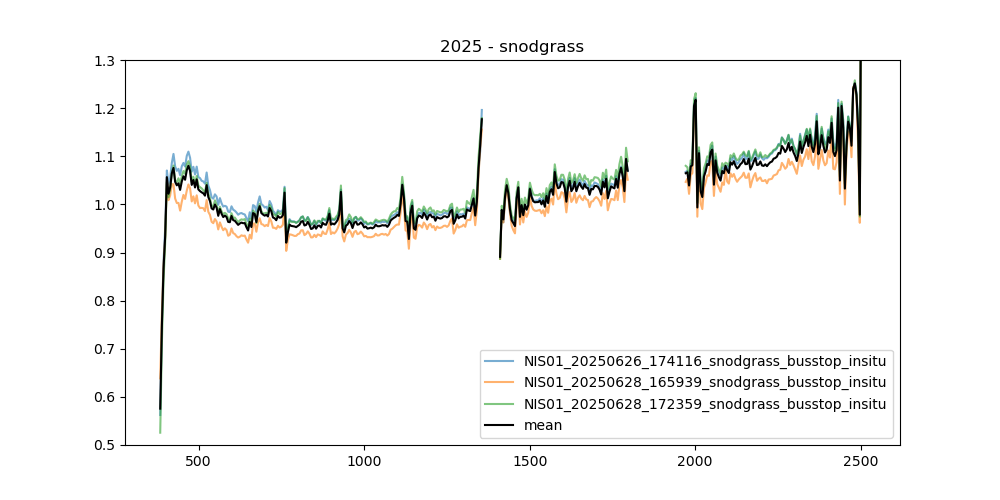

In [13]:
fig = plt.figure(figsize=(10,5))

for fid in fids:
    rcc_ = rccs[fid]
    plt.plot(wl_nan, rcc_, label=fid, alpha=0.6)

plt.plot(wl_nan, rcc_mean, label='mean', color='black')

plt.ylim(0.5,1.3)
plt.title('2025 - snodgrass')
plt.legend()
plt.show()

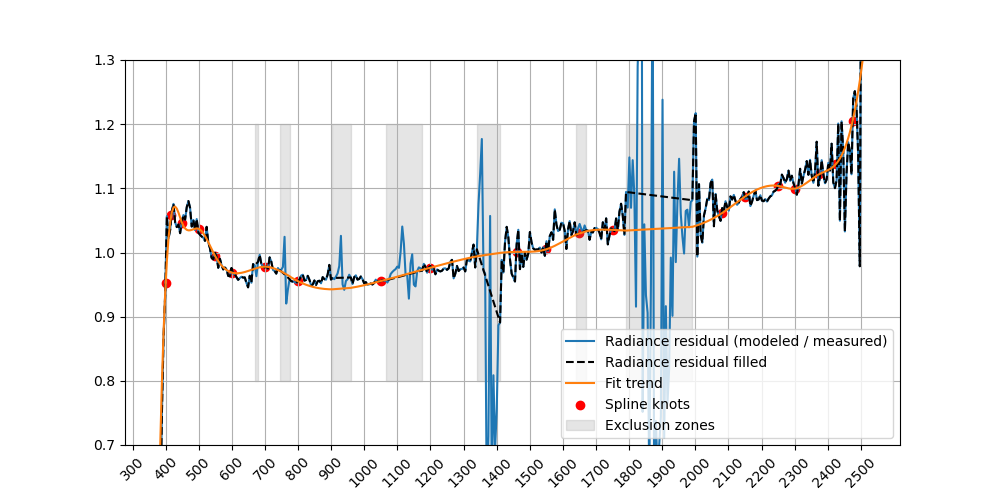

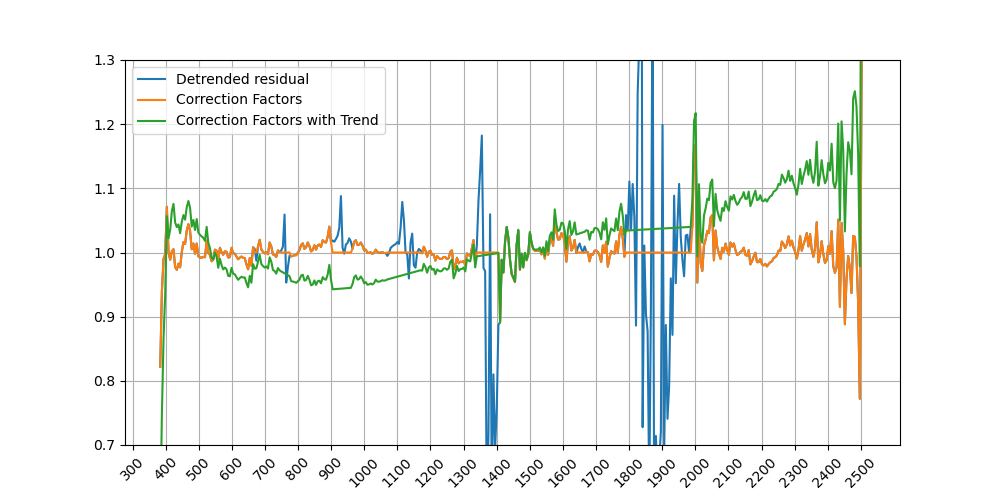

In [17]:
# add exclusion zones

wl = np.loadtxt('wavelengths_neon.txt')[:,1]*1000
wl = wl/1000

def wl2ind(wl0):
    return np.argmin(np.abs(wl - wl0))

def ind2wl(ind0):
    return wl[ind0]

radiance_ratio = np.loadtxt('2025/rccs/rcc_snodgrass_mean_6c.txt')
radiance_ratio_adjusted = radiance_ratio.copy()

knots = np.array([400,417,450,500,550,600,700,800,1050,1200,1460,1550,1650,1750,2080,2150,2250,2300,2375,2425, 2475], dtype=np.float32)/1000.

ignore_zones = [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.34, 1.410], [1.640,1.670], [1.79, 1.99], # atm absorption regions (narrower)
                [0.669, 0.679]]
                # [2.091, 2.350]]

knot_average_window = 1

for a, b in ignore_zones:
    wl_subset = wl[np.logical_and(wl > a, wl < b)]
    radiance_ratio_adjusted[np.logical_and(wl > a, wl < b)] = interp1d([a,b],[radiance_ratio_adjusted[wl2ind(a)],radiance_ratio_adjusted[wl2ind(b)]])(wl_subset)

inds = np.array([wl2ind(q) for q in knots])
spline_y = np.array([np.mean(radiance_ratio_adjusted[x-knot_average_window:x+knot_average_window+1]) for x in inds])
spline = splrep(knots,spline_y)
y_trend  = splev(wl, spline)

y_detrend = radiance_ratio/y_trend
y_correction = radiance_ratio/y_trend
for ez in ignore_zones:
    y_correction[np.logical_and(wl > ez[0], wl < ez[1])] = 1
    y_trend[np.logical_and(wl > ez[0], wl < ez[1])] = interp1d([ez[0],ez[1]],[y_trend[wl2ind(ez[0])],y_trend[wl2ind(ez[1])]])(wl[np.logical_and(wl > ez[0], wl < ez[1])])

wl = wl*1000

plt.figure(figsize=(10, 5))
plt.plot(wl, radiance_ratio, label='Radiance residual (modeled / measured)')
plt.plot(wl, radiance_ratio_adjusted, label='Radiance residual filled', c='black',ls='--')
plt.plot(wl, y_trend, label='Fit trend')
plt.scatter(knots*1000, spline_y, color='r', label='Spline knots')
for _el, el in enumerate(ignore_zones):
    if _el == 0:
        plt.fill_between(np.array(el)*1000, 0.8, 1.2, color='grey', alpha=0.2, label='Exclusion zones')
    else:
        plt.fill_between(np.array(el)*1000, 0.8, 1.2, color='grey', alpha=0.2)

plt.ylim([0.7, 1.3])
plt.xticks(np.arange(300,2600,100),rotation=45)
plt.grid()
plt.legend()

plt.figure(figsize=(10, 5))
plt.plot(wl, y_detrend, label='Detrended residual')
plt.plot(wl, y_correction, label='Correction Factors')
plt.plot(wl, y_correction*y_trend, label='Correction Factors with Trend')
plt.ylim([0.7, 1.3])
plt.xticks(np.arange(300,2600,100),rotation=45)
plt.grid()
plt.legend()

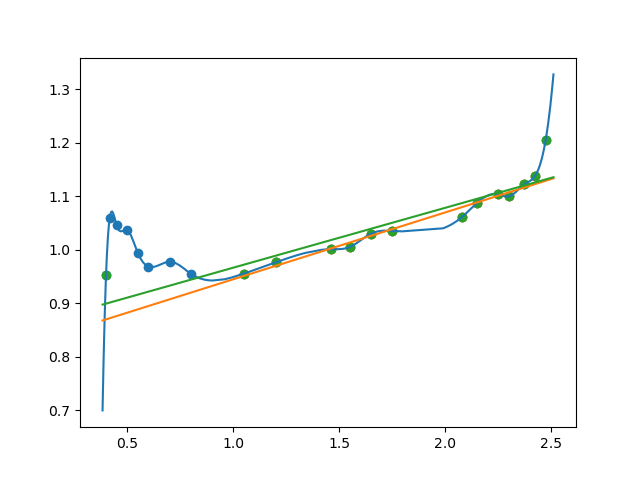

In [74]:
# remove blue section of trend - just fit one straight line?

knots_y = np.array([np.mean(radiance_ratio_adjusted[x-knot_average_window:x+knot_average_window+1]) for x in inds])
keep_knots_y = knots_y[8:-1]
keep_knots_x = knots[8:-1]
m, b = np.polyfit(keep_knots_x, keep_knots_y, 1)
line_y = m * wl/1000 + b

idx = np.r_[0, 8:len(knots_y)] # going with this one... orange line too extreme?
keep_knots_y_2 = knots_y[idx]
keep_knots_x_2 = knots[idx]
m, b = np.polyfit(keep_knots_x_2, keep_knots_y_2, 1)
line_y_2 = m * wl/1000 + b

fig = plt.figure()
plt.scatter(knots, knots_y)
plt.plot(wl/1000, y_trend)
plt.scatter(keep_knots_x, keep_knots_y)
plt.plot(wl/1000, line_y)

plt.scatter(keep_knots_x_2, keep_knots_y_2)
plt.plot(wl/1000, line_y_2)

plt.show()

In [84]:
# high frequency + linear trend, export

rcc_out = y_correction*line_y_2

1.1035674614883286 1.0925317868734454


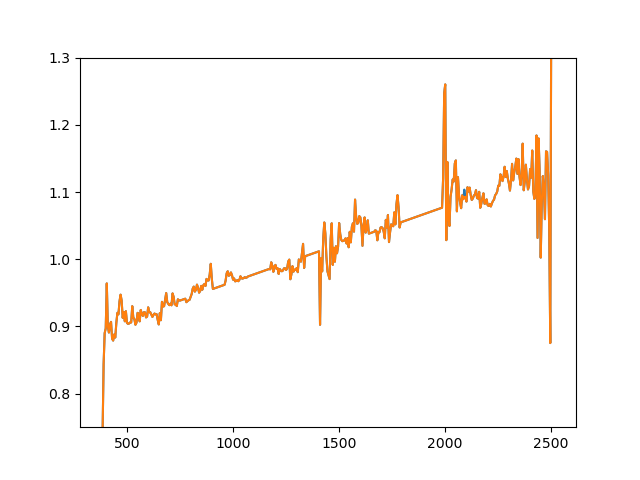

In [87]:
# Further adjustment... 

rcc_detrended_adjusted = rcc_out.copy()

i2091 = closest_wl(2091)

rcc_detrended_adjusted[i2091] = rcc_out[i2091]*0.99

print(rcc_out[i2091], rcc_detrended_adjusted[i2091])

fp_out = '2025/rccs/rcc_snodgrass_mean_6c_processed.txt'
np.savetxt(fp_out, rcc_detrended_adjusted)

fig = plt.figure()
plt.plot(wl, rcc_out, label='rcc_detrended')
plt.plot(wl, rcc_detrended_adjusted, label='rcc_detrended_adjusted')
plt.ylim(0.75, 1.3)
plt.xlim()
plt.show()

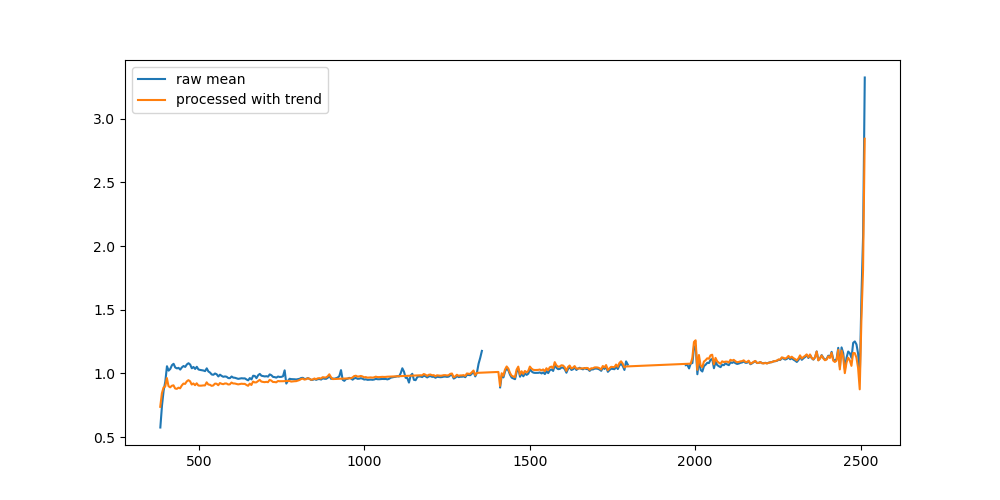

In [88]:
rcc_out = np.loadtxt('2025/rccs/rcc_snodgrass_mean_6c_processed.txt')

fig = plt.figure(figsize=(10,5))

plt.plot(wl_nan, radiance_ratio, label='raw mean')
plt.plot(wl, rcc_out, label='processed with trend')

plt.legend()
plt.show()

In [89]:
# check for further adjustments

rcc = np.loadtxt('2025/rccs/rcc_snodgrass_mean_6c_processed.txt')

test_fids = [x for x in single_px.keys() if 'snodgrass' not in x]
test_fids

['NIS01_20250614_177824_almo',
 'NIS01_20250626_165802_airpark',
 'NIS01_20250627_155921_matterhorn_lot',
 'NIS01_20250628_160551_airpark',
 'NIS01_20250628_174221_matterhorn_lot',
 'NIS01_20250629_150841_matterhorn_lot',
 'NIS01_20250702_162359_coal_creek',
 'NIS01_20250709_164963_upta',
 'NIS01_20250709_166260_upta']

In [90]:
# retrieve rfl w adjusted radiance for each bright, dark test target

alg_rfl_with_rcc = []
alg_rfl_no_rcc = []
analytical_rfl = []

for fid in test_fids:
    print(fid)
    try:
        fp_config = glob(os.path.join(base_dir, f'{fid}_6c', 'config', '*_isofit.json'))[0]
        config = configs.create_new_config(fp_config)
    
        # set up forward model, io, inv according to config
        fm = ForwardModel(config) # loads pre-built LUT
        io = IO(config, fm)
        inv = Inversion(config, fm)
    
        targets = single_px[fid].keys()
        for target in targets:
            print(fid, target)
            # load the single pixel representation
            rdn_ = single_px[fid][target]['rdn']
            obs_ = single_px[fid][target]['obs']
            loc_ = single_px[fid][target]['loc']
            geom = Geometry(obs=obs_, loc=loc_)
            
            # adjust rdn
            meas = rdn_.copy()
            meas = meas*rcc    
            
            # run isofit per px
    
            # no rcc
            states=inv.invert(rdn_, geom)
            x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
            x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, rdn_, geom)
            alg_rfl_no_rcc.append(x_alg)
            
            # with rcc
            states=inv.invert(meas, geom)
            x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
            x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
            alg_rfl_with_rcc.append(x_alg)
    
            rfl_est = fm.surface.fit_params(x_alg, geom)
            x0 = np.concatenate([rfl_est, x_RT, x_instrument])
            states, _ = invert_analytical(inv.fm, inv.winidx, meas, geom, np.copy(x0), states[-1,:], num_iter = 1, hash_table = OrderedDict(), hash_size = 500)
            out_rfl_est = states[-1, fm.idx_surf_rfl]        
            analytical_rfl.append(out_rfl_est)
    except: print(fid, 'failed')

INFO:root:Loading config file: 2025/rccs/NIS01_20250626_165802_airpark_6c/config/NIS01_20250626_165802_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/rccs/NIS01_20250626_165802_airpark_6c/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


NIS01_20250614_177824_almo
NIS01_20250614_177824_almo failed
NIS01_20250626_165802_airpark


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


NIS01_20250626_165802_airpark dark


INFO:root:Loading config file: 2025/rccs/NIS01_20250627_155921_matterhorn_lot_6c/config/NIS01_20250627_155921_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/rccs/NIS01_20250627_155921_matterhorn_lot_6c/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


...

NIS01_20250629_150841_matterhorn_lot bright


INFO:root:Loading config file: 2025/rccs/NIS01_20250702_162359_coal_creek_6c/config/NIS01_20250702_162359_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2025/rccs/NIS01_20250702_162359_coal_creek_6c/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


NIS01_20250629_150841_matterhorn_lot failed
NIS01_20250702_162359_coal_creek


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


NIS01_20250702_162359_coal_creek dark
NIS01_20250702_162359_coal_creek failed
NIS01_20250709_164963_upta
NIS01_20250709_164963_upta failed
NIS01_20250709_166260_upta
NIS01_20250709_166260_upta failed


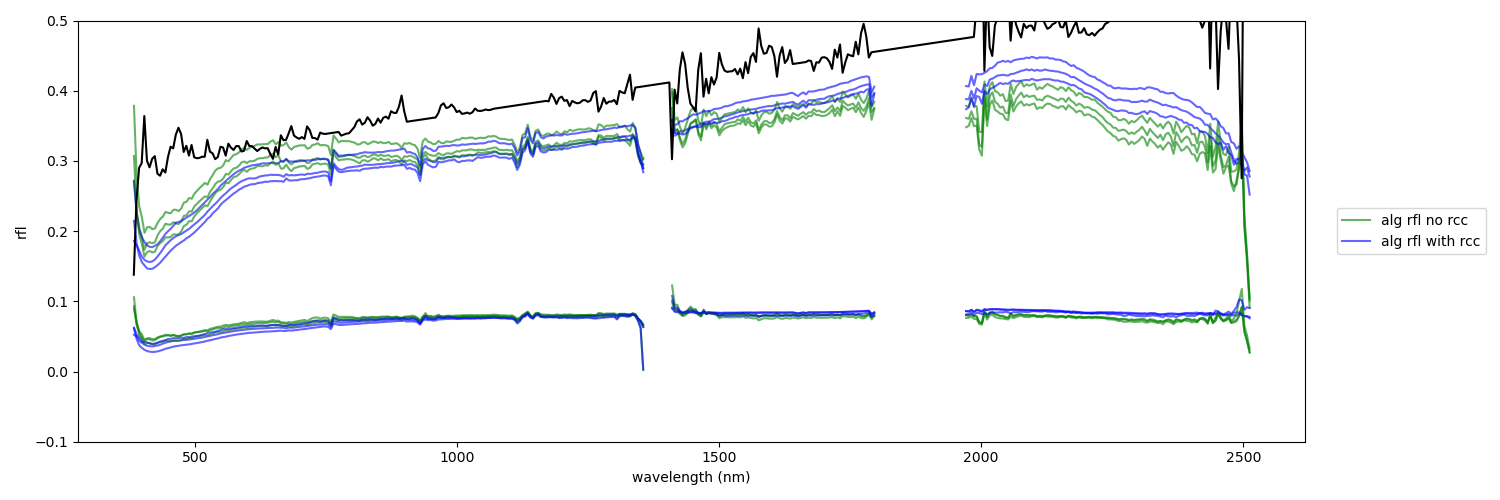

In [91]:
# set up rcc rfl interpolation

exp_arr = np.array([2,5,10,13,20,27,37,42,50,60,75,85,100,150,180,190,206,210,220,235,250,260,270,279,320,340,350,356,364,368,375,380,385,392,400,405,410,415,420,425])

bin_size = 2
exp_lis = [np.mean(wl_nan[x-bin_size:x+bin_size]) for x in exp_arr]

fig = plt.figure(figsize=(15,5))

for i in range(len(alg_rfl_no_rcc)):
    if i==0:
        plt.plot(wl_nan, alg_rfl_no_rcc[i], alpha=0.6, color='green', label='alg rfl no rcc')
        plt.plot(wl_nan, alg_rfl_with_rcc[i], alpha=0.6, color='blue', label='alg rfl with rcc')
        # rfl_lis = [np.mean(alg_rfl_with_rcc[i][x-bin_size:x+bin_size]) for x in exp_arr]
        # interp = np.interp(wl_nan, exp_lis, rfl_lis)
        # plt.plot(wl_nan, interp, alpha=0.6, color='purple', label='interp')
        # plt.plot(wl_nan, analytical_rfl[i], alpha=0.6, color='purple', label='analytical line')
    else:    
        plt.plot(wl_nan, alg_rfl_no_rcc[i], alpha=0.6, color='green')
        plt.plot(wl_nan, alg_rfl_with_rcc[i], alpha=0.6, color='blue')
        # rfl_lis = [np.mean(alg_rfl_with_rcc[i][x-bin_size:x+bin_size]) for x in exp_arr]
        # interp = np.interp(wl_nan, exp_lis, rfl_lis)
        # plt.plot(wl_nan, interp, alpha=0.6, color='purple')
        # plt.plot(wl_nan, analytical_rfl[i], alpha=0.6, color='purple')

plt.plot(wl, rcc-0.6, color='black')

plt.ylabel('rfl')
plt.xlabel('wavelength (nm)')

plt.ylim(-0.1, 0.5)

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()

plt.show()

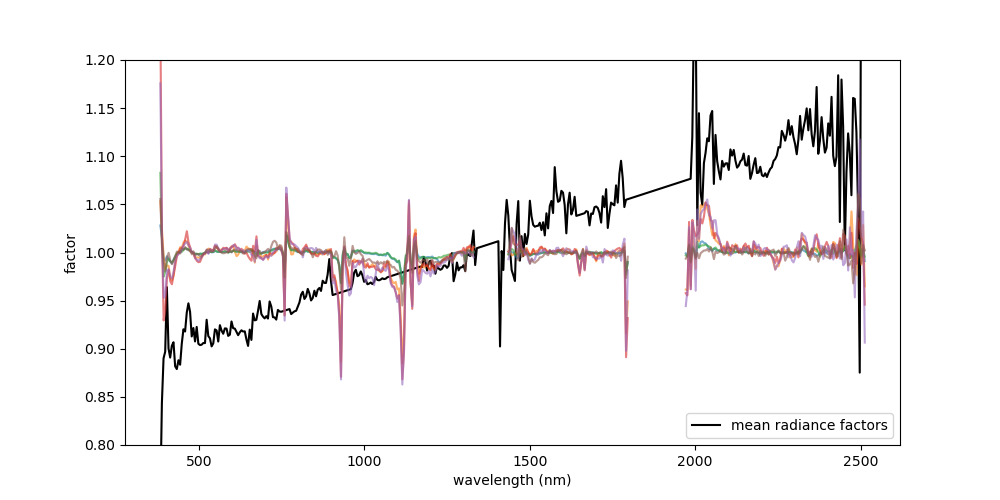

In [92]:
## from Phil - 

# visualize the delta between x_alg (from the rcc-adjusted rdn) and a smoothed linear interpolation of x_alg
# compare those deltas w/ rccs, across all bright/dark targets
# regions where the noise (deltas) are similar across targets and follow the trends of the rccs = regions we want to interpolate across

deltas = []

fig = plt.figure(figsize=(10,5))

exp_arr = np.array([2,5,10,13,20,27,37,42,50,60,75,85,100,150,180,190,206,210,220,235,250,260,270,279,320,340,350,356,364,368,375,380,385,392,400,405,410,415,420,425])
bin_size = 2
exp_lis = [np.mean(wl_nan[x-bin_size:x+bin_size]) for x in exp_arr]

plt.plot(wl, rcc, color='black', label='mean radiance factors')

for i in range(len(alg_rfl_with_rcc)):
    rfl_lis = [np.mean(alg_rfl_with_rcc[i][x-bin_size:x+bin_size]) for x in exp_arr]
    interp = np.interp(wl_nan, exp_lis, rfl_lis)
    delta = alg_rfl_with_rcc[i] - interp
    deltas.append(delta)
    plt.plot(wl_nan, delta*5+1, alpha=0.6)
    
plt.ylabel('factor')
plt.xlabel('wavelength (nm)')
plt.ylim(0.8, 1.2)
plt.legend()
plt.show()